## Модель предсказания вероятности клика (CTR) на рекламу

## Постановка задачи и требования

### Задача:
- построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление.

### Требования:

Калибровка:
- предсказанные вероятности кликов должны максимально точно соответствовать и их реальной частоте 

Метрики:
- PR-AUC — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы
- Log Loss позволит оценить точность предсказанных вероятностей. 
- Оценка Бриера измеряет и точность, и калибровку модели



## 1. Подготовка среды и загрузка данных

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.feature_selection import VarianceThreshold

In [4]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [5]:
# загрузка данных
df = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [6]:
df.shape

(50000, 34)

In [7]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

## 2. Исследовательский анализ данных (EDA)


#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

### 2.1 Базовая информация 

In [9]:
df.shape

(50000, 34)

In [10]:
df.isna().sum().sum()  # явных пропусков нет

np.int64(0)

In [11]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns
num_cols = df.select_dtypes(include=['int64', 'float']).columns
cat_cols, len(cat_cols), num_cols, len(num_cols)

(Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
        'app_category', 'device_id', 'device_ip', 'device_model',
        'ml_feature_2', 'ml_feature_7'],
       dtype='str'),
 11,
 Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type',
        'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
        'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
        'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'],
       dtype='str'),
 23)

#### Датасет:

- 50000 объектов
- 33 признака и целевая переменная 
- 11 категориальных и 22 числовых признака, целевая переменная в виде числа
- данные не содержат явных пропусков

#### Пользователи и реклама:

Идентификаторы и временные метки:
- id — уникальный идентификатор записи о показе баннера;
- hour — час, в который был показан баннер, в формате YYMMDDHH.

Характеристики рекламной площадки ( Site ):
- site_id — идентификатор веб-сайта, на котором был показан баннер;
- site_domain — домен веб-сайта;
- site_category — тематическая категория веб-сайта.

Характеристики рекламируемого приложения ( App ):
- app_id — идентификатор рекламируемого мобильного приложения;
- app_domain — домен рекламируемого приложения;
- app_category — категория рекламируемого приложения.

Характеристики устройства и соединения пользователя:
- device_id — идентификатор браузера или устройства;
- device_ip — IP-адрес устройства;
- device_model — модель устройства;
- device_type — тип устройства пользователя: например, смартфон, планшет, ПК;
- device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

Характеристики рекламного баннера и аукциона:
- C1 — анонимизированный признак, характеризующий контекст показа;
- banner_pos — позиция баннера на веб-странице;
- C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

Машинно-сгенерированные признаки (ML Features):
- ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

Целевая переменная:
- click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.



---

### 2.2 Анализ целевой переменной

In [12]:
target = df['click']

In [13]:
# Соотношение классов
target.value_counts() / len(target) * 100

click
0    82.794
1    17.206
Name: count, dtype: float64

Анализ:
- среди классов наблюдается дисбаланс: 83% пропусков рекламы, 17% кликов

Рекомендация:
- при разделениий на выброки необходимо применять стратификацию

---

### 2.3 Анализ признаков

#### Категориальные признаки

In [14]:

df[cat_cols].nunique()

site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
ml_feature_2         5
ml_feature_7         3
dtype: int64

Анализ:
- уникальных значений для site_id, site_domain, app_id, device_id, device_ip, device_model довольно много (>900). Среди этих признаков имеются техническими данные, связянными со сбором информации. Кандиданты на удаление.
- проведем визуальных анализ распределения целевого класса среди категориальных признаков, где уникальных значений немного (<100).

#### Соотношение целевых классов внутри признаков

In [15]:
# для категориальных признаков cat_cols строим столбчатые диаграммы

def plot_bar_target_class(df: pd.DataFrame, target_name: str, cat_col: str):

    df_chain_unstack = df.groupby(cat_col)[target_name].value_counts(normalize=True).unstack(fill_value=0).sort_values(by=1)

    df_chain_unstack.plot(kind='bar', figsize=(10, 6),)

    plt.title(f'Доля целевых классов для признака {cat_col}') 
    plt.ylabel('Доля') 
    plt.xlabel(cat_col) 
    plt.xticks(rotation=45)  
    plt.legend()  

    plt.show()

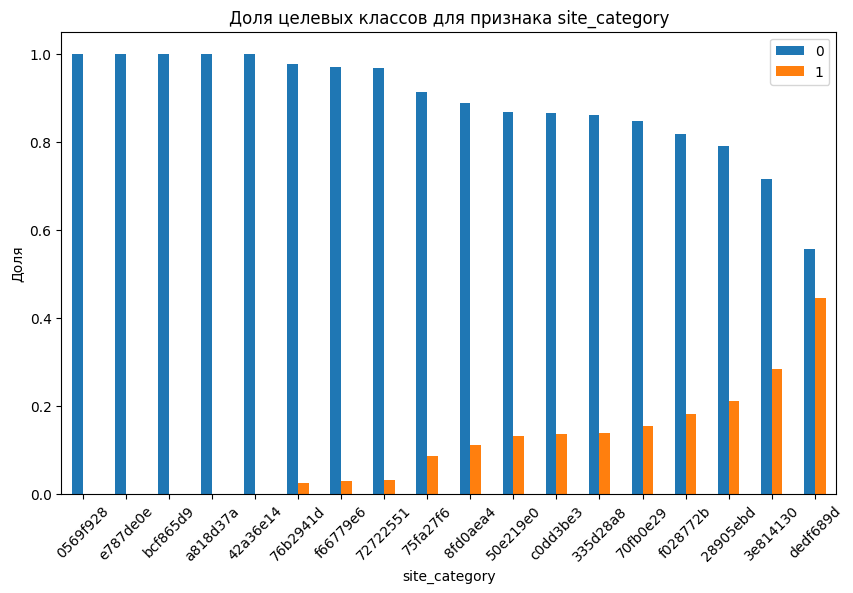

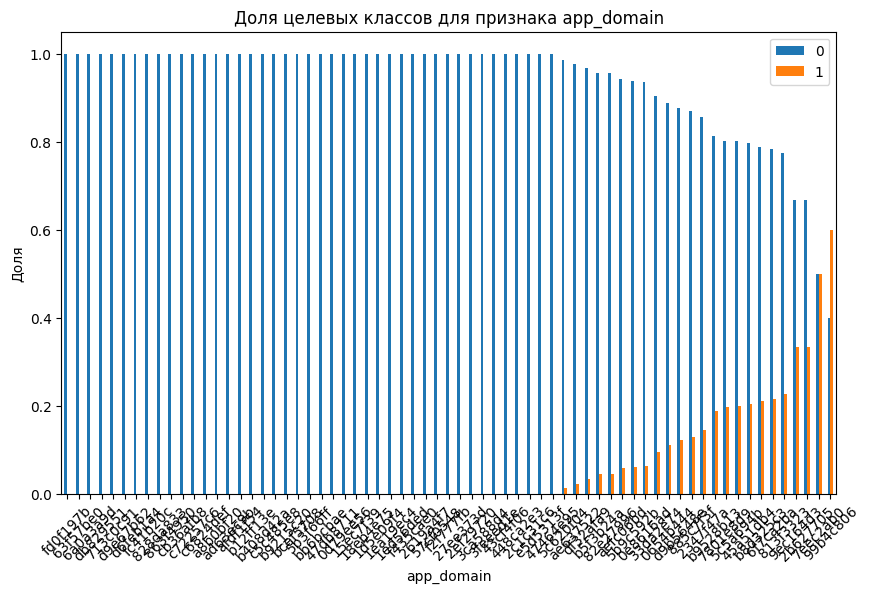

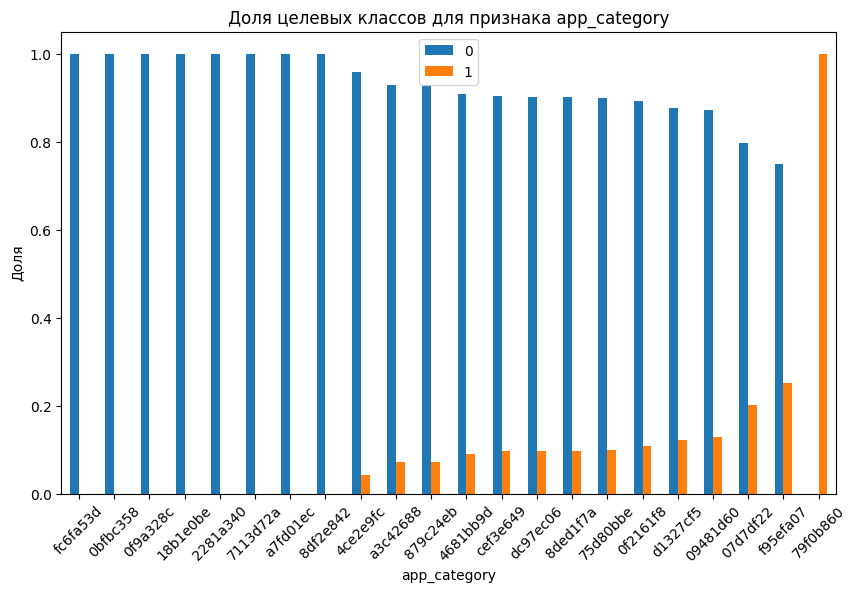

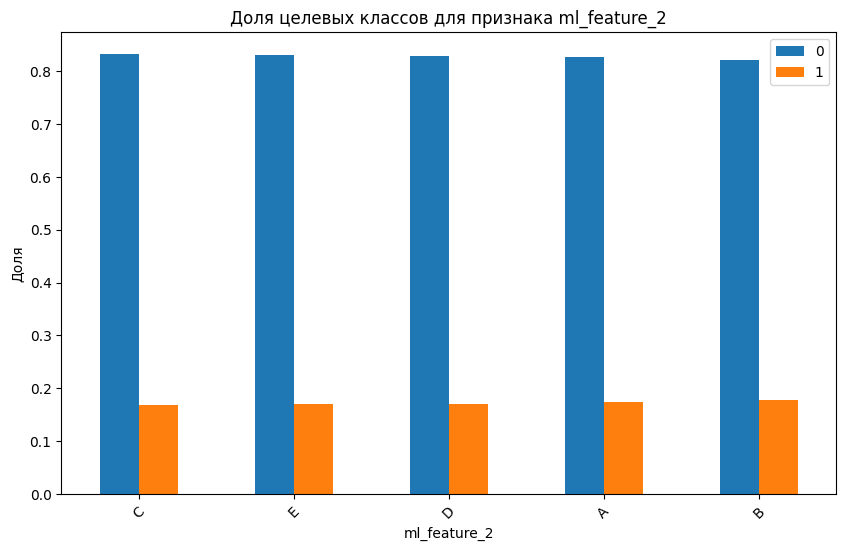

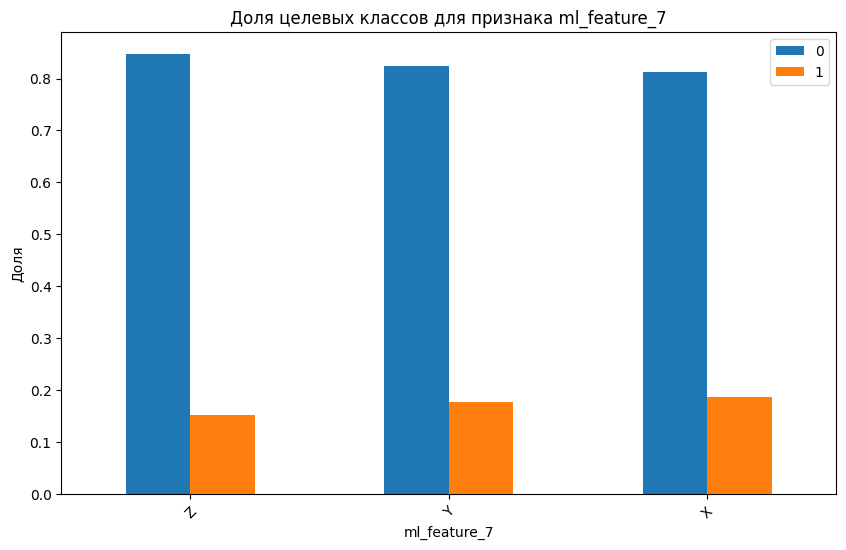

In [16]:
cat_cols_to_analyze = ['site_category', 'app_domain', 'app_category', 'ml_feature_2', 'ml_feature_7']
for name in cat_cols_to_analyze:
    plot_bar_target_class(df=df, target_name='click', cat_col=name)

Анализ:
- доля целевых классов внутри признаков ml_feature_7, ml_feature_2 практически не отличается
- для признаков 'site_category', 'app_domain', 'app_category' есть существенные различия по долям целевого класса

Рекомендация:
- ml_feature_7, ml_feature_2 - кандидаты на удаление, поскольку их связь с целевой переменной минимальна

In [17]:
cat_cols

Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
       'app_category', 'device_id', 'device_ip', 'device_model',
       'ml_feature_2', 'ml_feature_7'],
      dtype='str')

interval columns not set, guessing: ['click']


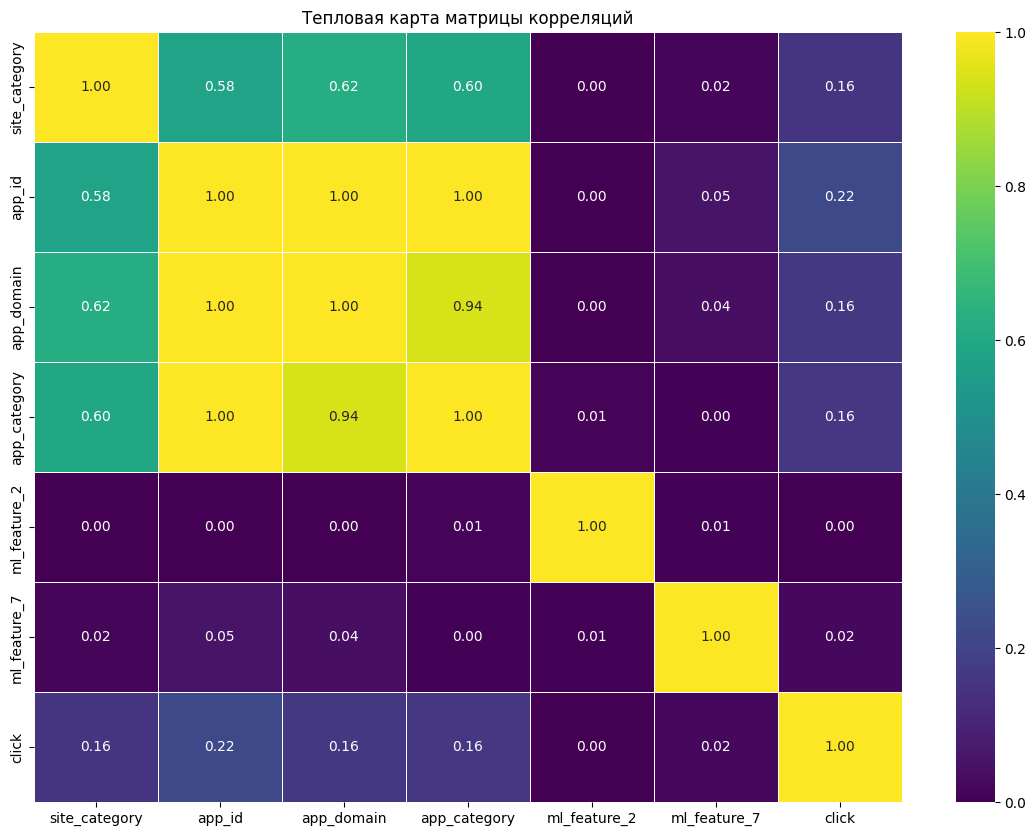

Корреляция переменных с 'click':
click            1.000000
app_id           0.221436
app_domain       0.161289
app_category     0.156537
site_category    0.155008
ml_feature_7     0.022622
ml_feature_2     0.003790
Name: click, dtype: float64


In [18]:
# Посчитаем матрицу корреляций для категорий, где количество уникальных значений позволяет это сделать
cols_to_show = ['site_category', 'app_id', 'app_domain','app_category','ml_feature_2', 'ml_feature_7', 'click']
corr_matrix = df[cols_to_show].phik_matrix()

plt.figure(figsize=(14, 10)) 

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

plt.title('Тепловая карта матрицы корреляций')
plt.show()
print("Корреляция переменных с 'click':")
print(corr_matrix['click'].sort_values(ascending=False))

Анализ:
- высокая корреляция (от 0.94 и до 1) между признаками: app_id, app_domain, app_category. Для избежания проблемы мультиколлинеарности стоит оставить только один из них. Можно оставить наиболее скоррелированный с целевой переменной
-  наиболее связан с click признак app_id: 0.221436
- наименее связанные признаки с click: 
    - ml_feature_7:     0.022622
    - ml_feature_2:     0.003790

#### Кодирование категориальных признаков

- признаки, для которых уникальных значений <10 будем кодировать OneHotEncoder
- признаки с большим кол-вом уникальных значений будем кодировать с помощью TargetEncoding, чтобы не раздувать размерность задачи

In [19]:
cat_nunique = df[cat_cols].nunique()
one_hot_code_cols = cat_nunique[cat_nunique < 10]

print('кандидаты для кодирования OneHot: ')
one_hot_code_cols

кандидаты для кодирования OneHot: 


ml_feature_2    5
ml_feature_7    3
dtype: int64

In [20]:
target_code_cols = cat_nunique[cat_nunique > 10]

print('кандидаты для кодирования TargetEncoder: ')
target_code_cols

кандидаты для кодирования TargetEncoder: 


site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
dtype: int64


#### Количественные признаки

In [21]:
df[num_cols].head()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,1,0,17614,320,50,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1,0,15701,320,50,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,1,0,17914,320,50,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,1,0,21611,320,50,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1,0,15702,320,50,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


In [22]:
df[num_cols].describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


#### корреляционный анализ

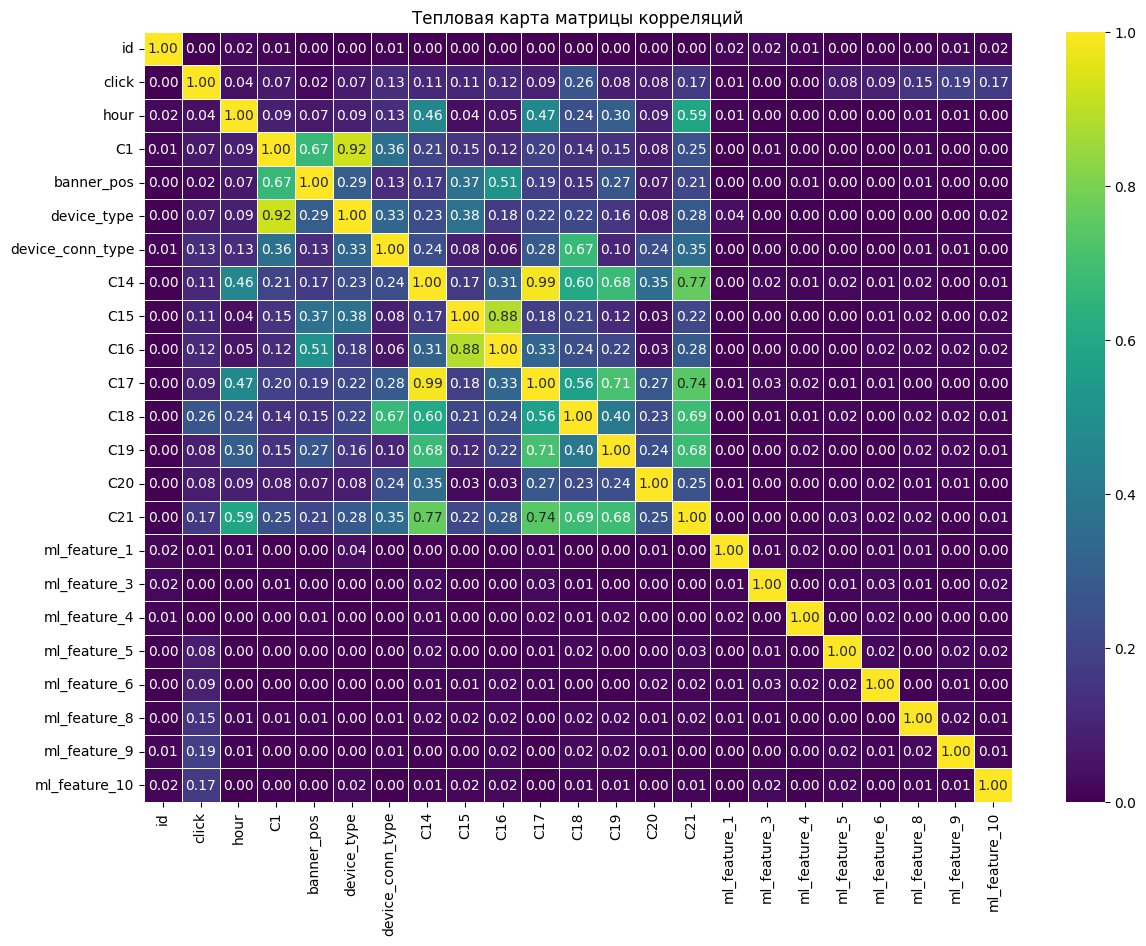

Корреляция переменных с 'click':
click               1.000000
C18                 0.257840
ml_feature_9        0.187801
ml_feature_10       0.169983
C21                 0.166235
ml_feature_8        0.153598
device_conn_type    0.129954
C16                 0.117539
C14                 0.112890
C15                 0.106817
ml_feature_6        0.091314
C17                 0.091306
C19                 0.084697
ml_feature_5        0.080014
C20                 0.075979
device_type         0.071790
C1                  0.067731
hour                0.042935
banner_pos          0.022605
ml_feature_1        0.010056
ml_feature_4        0.000000
ml_feature_3        0.000000
id                  0.000000
Name: click, dtype: float64


In [23]:
# Посчитаем матрицу корреляций
corr_matrix = df[num_cols].phik_matrix(interval_cols=num_cols)

plt.figure(figsize=(14, 10)) 

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

plt.title('Тепловая карта матрицы корреляций')
plt.show()
print("Корреляция переменных с 'click':")
print(corr_matrix['click'].sort_values(ascending=False))

Анализ:
- высокие коэффициенты корреляции:
    - C14, C17 -  0.99
    - C1, device_type - 0.92
    - C15, C16 - 0.88

- наиболее скоррелированные признаки с целевой переменной (их точно стоит оставить): 
    - C18                 0.257840
    - ml_feature_9        0.187801
    - ml_feature_10       0.169983
    - C21                 0.166235
    - ml_feature_8        0.153598
    - device_conn_type    0.129954
    - C16                 0.117539
    - C14                 0.112890

- наименее скорреированные с целевой переменной (кандидаты на удаление):
    - banner_pos          0.022605
    - ml_feature_1        0.010056
    - ml_feature_4        0.000000
    - ml_feature_3        0.000000
    - id                  0.000000

Рекомендация:
- для избежания проблемы мультиколлинеарности стоит рассмотреть удаление одного признака из пары сильно скоррлированных 
- мало скоррелированные признаки с целевой переменной стоит рассмотреть к удалению

### Отбор признаков

По результатам анализа выше проведем фильтрацию явно бесполезных признаков: идентификаторы пользователей, сайтов, устройств, домены сайтов, ip адреса и модели устройств пользователей:
- id, site_id, site_domain, device_id, device_ip, device_model

Остальные признаки потенциально полезны для анализа

In [24]:
df = df.drop(columns=['id', 'site_id', 'site_domain', 'device_id', 'device_ip', 'device_model'])

In [25]:
df.head()

,click,hour,C1,banner_pos,site_category,app_id,app_domain,app_category,device_type,device_conn_type,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1,14102100,1005,1,f028772b,ecad2386,7801e8d9,07d7df22,1,0,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,0,14102100,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,0,14102100,1005,0,f028772b,ecad2386,7801e8d9,07d7df22,1,0,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,0,14102100,1005,0,50e219e0,39cfef32,d9b5648e,0f2161f8,1,0,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,0,14102100,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


#### Анализ выбросов в количественных признаках 

In [26]:
num_cols_upd = [
    'click', 'hour', 'C1', 'banner_pos', 'device_type',
       'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]
df[num_cols_upd].head()

,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1,14102100,1005,1,1,0,17614,320,50,1993,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,0,14102100,1005,0,1,0,15701,320,50,1722,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,0,14102100,1005,0,1,0,17914,320,50,2043,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,0,14102100,1005,0,1,0,21611,320,50,2480,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,0,14102100,1005,0,1,0,15702,320,50,1722,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


In [48]:
def boxplot_describe(feature_names_list: list[str], df: pd.DataFrame=df, fig_sz: tuple[int, int] = (12, 5), target='click'):
    n_features = len(feature_names_list)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_sz[0], fig_sz[1] * n_rows))
    axes = axes.flatten() 

    idx_1 = np.where(df[target] == 1)
    idx_0 = np.where(df[target] == 0)
    for i, feature in enumerate(feature_names_list):
        ax = axes[i]
        data = df[feature]

        data_1 = data.iloc[idx_1]
        data_0 = data.iloc[idx_0]

        sns.histplot(data=data_0, ax=ax, alpha=0.5, label=f'{target} = 0')
        sns.histplot(data=data_1, ax=ax, alpha=0.5, label=f'{target} = 1')

        ax.set_title(f'Распределение признака {feature} по классам {target}')
        ax.set_xlabel(feature)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

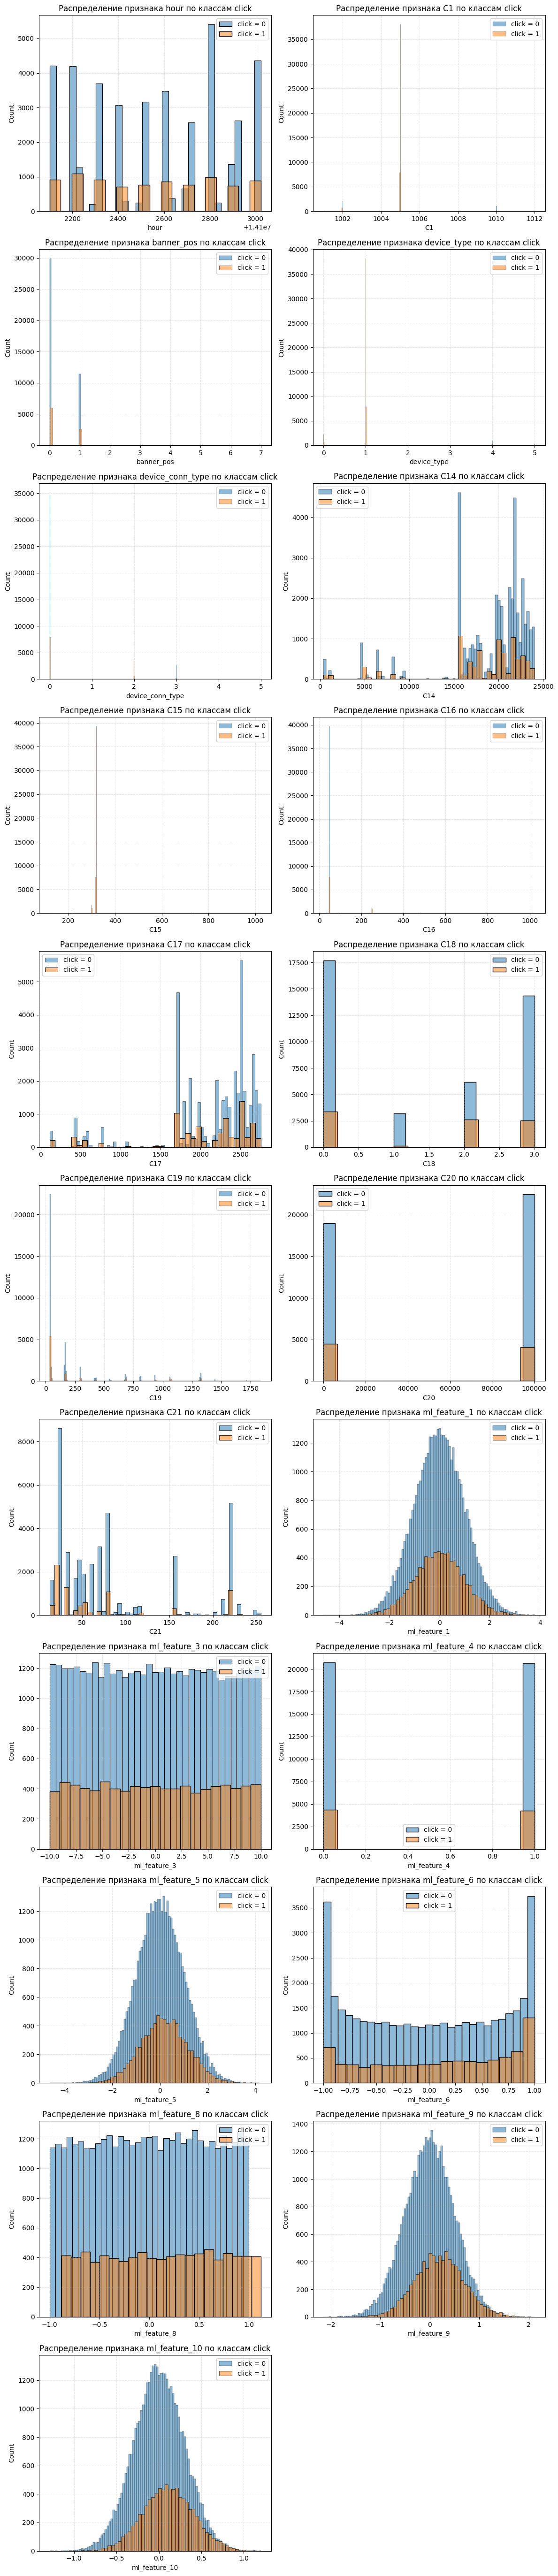

In [49]:
boxplot_describe(feature_names_list=num_cols_upd[1:], df=df)

In [54]:
def get_constant_features(df: pd.DataFrame, threshold: float = 0.):
    # Числовые признаки
    numerical_columns = df.select_dtypes(include=[np.number]).columns
    numerical_data = df[numerical_columns]

    # Используем VarianceThreshold с порогом threshold 
    vs_quasi = VarianceThreshold(threshold=threshold) 

    numerical_columns = df.select_dtypes(include=[np.number]).columns
    numerical_data = df[numerical_columns]
    vs_quasi.fit(numerical_data)
    quasi_num_cols = [col for col, keep in zip(numerical_columns, vs_quasi.get_support()) if not keep]

    # Квази-константные категориальные признаки
    quasi_cat_cols = [col for col in df.select_dtypes(include=['object', 'str']).columns
                    if df[col].value_counts(normalize=True).iloc[0] > (1 - threshold)]

    # Объединяем
    quasi_constant_cols = quasi_num_cols + quasi_cat_cols
    print("константные признаки: ", quasi_constant_cols, ', threashold: ', threshold)


In [55]:
get_constant_features(df, threshold=0.)

константные признаки:  [] , threashold:  0.0


In [56]:
get_constant_features(df, threshold=0.1)

константные признаки:  ['ml_feature_10'] , threashold:  0.1


Анализ:

- константных признаков нет. 
- Среди квази-константных можно выделить ml_feature_10 с дисперсией менее 0.1. Но по форме распределения этого признака он константным не выглядит. Пока оставляем. 

Распределения с выбросами, требующие дополнительного анализа:
- 'C1', 'banner_pos', 'device_type',
       'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_1', 'ml_feature_4', 'ml_feature_5', 'ml_feature_9', 'ml_feature_10'

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.